In [1]:
import statsmodels.formula.api as sm
import matplotlib.pyplot as plt
from matplotlib.cm import get_cmap
from matplotlib.lines import Line2D
import seaborn as sns
import pandas as pd
import numpy as np
from statsmodels.stats.anova import anova_lm
from statsmodels.formula.api import logit, ols
from statsmodels.tools import add_constant


def display_(df):
    with pd.option_context('display.max_rows', None, 'display.max_columns', None):  # more options can be specified also
        display(df)

# Load data

In [2]:
DF = pd.read_csv('data/Mar2023/combined_filtered.csv')

# Simple proportion correct across time during practice (split by family)

,rule,condition,famInd,level_3,trialsCumCount,trialsComplete,correct
0,fi,blocked,1,0,1.0,67.902655,0.610619
1,fi,blocked,1,1,1.5,68.402655,0.548673
2,fi,blocked,1,2,2.0,68.902655,0.598820
3,fi,blocked,1,3,2.5,69.402655,0.617257
4,fi,blocked,1,4,3.0,69.902655,0.631858
...,...,...,...,...,...,...,...
760,fi,interleaved,4,760,52.5,156.455357,0.704464
761,fi,interleaved,4,761,53.5,159.452679,0.694643
762,fi,interleaved,4,762,54.5,162.465179,0.688393
763,fi,interleaved,4,763,55.5,165.466071,0.689286


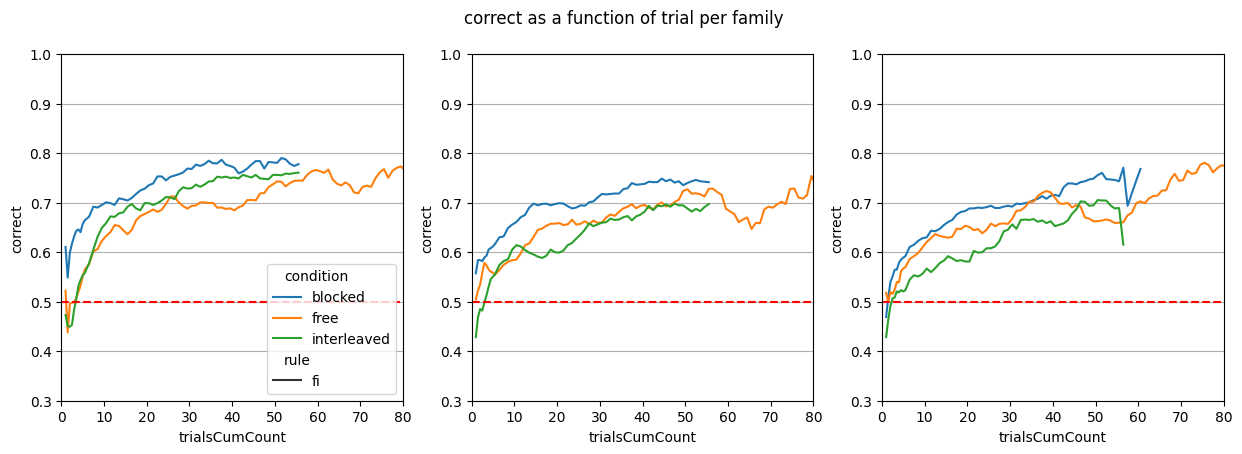

In [3]:
v = 'correct'
save = 0

df = DF[DF.feedbackOn][['condition', 'famInd', 'trialsComplete', v, 'pid', 'rule']]
df['trialsCumCount'] = (df.groupby(['pid', 'famInd']).cumcount() + 1).astype(int)
df.sort_values(by=['rule', 'condition', 'pid', 'trialsComplete']).filter('rule,pid,condition,famInd,trialsComplete'.split(',')).to_csv('temp.csv', index=False)
df = df.groupby(['rule', 'condition', 'famInd', 'trialsCumCount']).mean().reset_index()
df = df.groupby(['rule', 'condition', 'famInd']).rolling(10, min_periods=1).mean().reset_index()
display(df)
fig = plt.figure(figsize=[15, 4.5])
for i, fam in enumerate([1, 3, 4]):
    ax = fig.add_subplot(1, 3, i+1)
    ax.set_ylim(0.3, 1.0)
    ax.set_xlim(0, 80)
    plotdf = df[df.famInd.eq(fam)]
    sns.lineplot(x='trialsCumCount', y=v, hue='condition', style='rule', data=plotdf, ax=ax, err_kws=dict(alpha=.5))
    ax.axhline(0.5, ls='--', color='r', label='Chance hit rate')
    ax.grid(axis='y')
    if i > 0:
        ax.get_legend().remove()
plt.suptitle(f'{v} as a function of trial per family')

if save:
    plt.savefig(f'plots/PRELIM_{v}PerTrialPerFam.png')

,rule,condition,famInd,level_3,trialsCumCount,trialsComplete,correct
0,fi,blocked,1,0,1.0,67.902655,0.610619
1,fi,blocked,1,1,1.5,68.402655,0.548673
2,fi,blocked,1,2,2.0,68.902655,0.598820
3,fi,blocked,1,3,2.5,69.402655,0.617257
4,fi,blocked,1,4,3.0,69.902655,0.631858
...,...,...,...,...,...,...,...
760,fi,interleaved,4,760,52.5,156.455357,0.704464
761,fi,interleaved,4,761,53.5,159.452679,0.694643
762,fi,interleaved,4,762,54.5,162.465179,0.688393
763,fi,interleaved,4,763,55.5,165.466071,0.689286


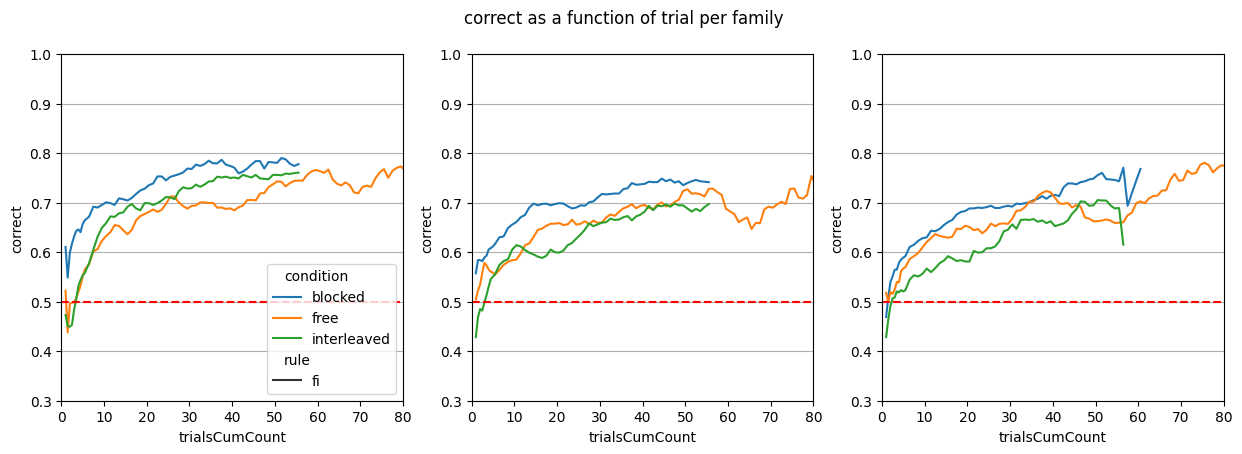

In [4]:
v = 'correct'
save = 0

df = DF[DF.feedbackOn][['condition', 'famInd', 'trialsComplete', v, 'pid', 'rule']]
df['trialsCumCount'] = (df.groupby(['pid', 'famInd']).cumcount() + 1).astype(int)
df.sort_values(by=['rule', 'condition', 'pid', 'trialsComplete']).filter('rule,pid,condition,famInd,trialsComplete'.split(',')).to_csv('temp.csv', index=False)
df = df.groupby(['rule', 'condition', 'famInd', 'trialsCumCount']).mean().reset_index()
df = df.groupby(['rule', 'condition', 'famInd']).rolling(10, min_periods=1).mean().reset_index()
display(df)
fig = plt.figure(figsize=[15, 4.5])
for i, fam in enumerate([1, 3, 4]):
    ax = fig.add_subplot(1, 3, i+1)
    ax.set_ylim(0.3, 1.0)
    ax.set_xlim(0, 80)
    plotdf = df[df.famInd.eq(fam)]
    sns.lineplot(x='trialsCumCount', y=v, hue='condition', style='rule', data=plotdf, ax=ax, err_kws=dict(alpha=.5))
    ax.axhline(0.5, ls='--', color='r', label='Chance hit rate')
    ax.grid(axis='y')
    if i > 0:
        ax.get_legend().remove()
plt.suptitle(f'{v} as a function of trial per family')

if save:
    plt.savefig(f'plots/PRELIM_{v}PerTrialPerFam.png')

# Simple proportion correct across time during practice (aggregated across families)

,rule,condition,famInd,level_3,trialsCumCount,trialsComplete,correct
0,fi,blocked,1,0,1.0,61.750000,0.600000
1,fi,blocked,1,1,1.5,62.250000,0.562500
2,fi,blocked,1,2,2.0,62.750000,0.595833
3,fi,blocked,1,3,2.5,63.250000,0.618750
4,fi,blocked,1,4,3.0,63.750000,0.637500
...,...,...,...,...,...,...,...
752,fi,interleaved,4,752,55.0,163.903896,0.690909
753,fi,interleaved,4,753,56.0,166.929870,0.693506
754,fi,interleaved,4,754,57.0,169.922078,0.698701
755,fi,interleaved,4,755,58.0,172.885714,0.711688


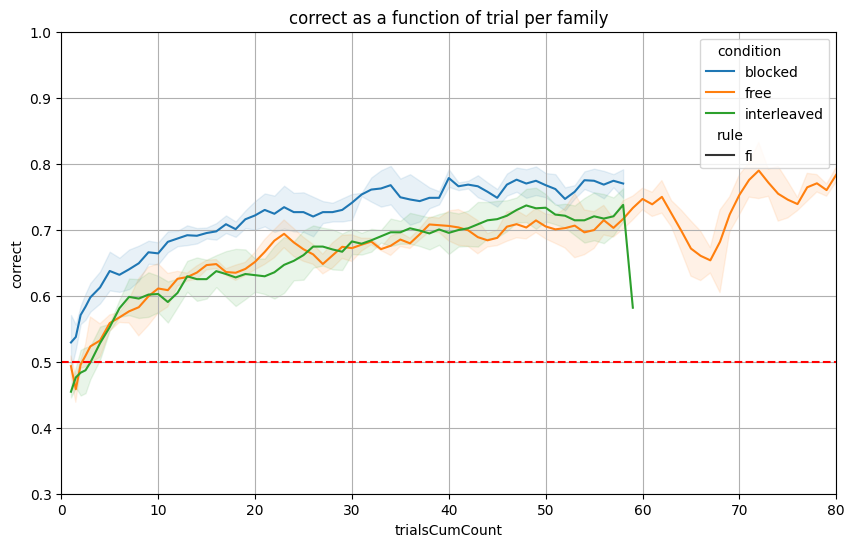

In [109]:
v = 'correct'
save = 1

df = DF[DF.feedbackOn][['condition', 'famInd', 'trialsComplete', v, 'pid', 'rule']]
df['trialsCumCount'] = (df.groupby(['pid', 'famInd']).cumcount() + 1).astype(int)
df.sort_values(by=['rule', 'condition', 'pid', 'trialsComplete']).filter('rule,pid,condition,famInd,trialsComplete'.split(',')).to_csv('temp.csv', index=False)
df = df.groupby(['rule', 'condition', 'famInd', 'trialsCumCount']).mean().reset_index()
df = df.groupby(['rule', 'condition', 'famInd']).rolling(5, min_periods=1).mean().reset_index()
display(df)
fig = plt.figure(figsize=[10, 6])
ax = fig.add_subplot(111)

ax.set_ylim(0.3, 1.0)
ax.set_xlim(0, 80)

sns.lineplot(x='trialsCumCount', y=v, hue='condition', style='rule', data=df, ax=ax, err_kws=dict(alpha=.1), errorbar=('ci', 90))
ax.axhline(0.5, ls='--', color='r', label='Chance hit rate')
ax.grid()
plt.title(f'{v} as a function of trial per family')

if save:
    plt.savefig(f'plots/PRELIM_{v}PerTrial_ALL.png')

# Test 1 and 2 performance

,rule,condition,pid,stage,correct,confidence
0,fi,blocked,565c40fbc121fe0005fc3b62,test1,0.822222,0.625889
1,fi,blocked,565c40fbc121fe0005fc3b62,test2,0.855556,0.639556
2,fi,blocked,567bdc76b7d79a0012b2738a,test1,0.527473,0.415055
3,fi,blocked,567bdc76b7d79a0012b2738a,test2,0.588889,0.593222
4,fi,blocked,572faa2cad131600100169b5,test1,0.811111,0.604778
...,...,...,...,...,...,...
671,fi,interleaved,64011d89460937cf59669000,test2,0.500000,0.657778
672,fi,interleaved,64012f5a283810b2f84795e7,test1,0.600000,0.648667
673,fi,interleaved,64012f5a283810b2f84795e7,test2,0.600000,0.614222
674,fi,interleaved,640612477c8f387ffe0b0dba,test1,0.733333,0.691000


ANOVA effect of condition on correct during test 1


,sum_sq,df,F,PR(>F)
condition,0.019659,2.0,1.002596,0.368024
Residual,3.284421,335.0,NaN,NaN


ANOVA effect of condition on accuracy during test 2


,sum_sq,df,F,PR(>F)
condition,0.085058,2.0,3.386127,0.035002
Residual,4.207519,335.0,NaN,NaN


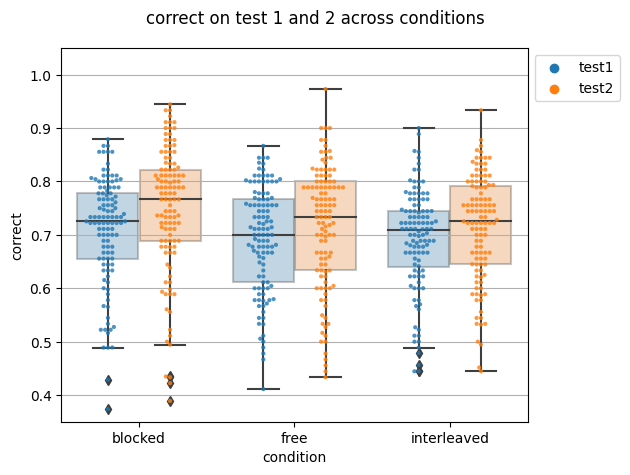

In [5]:
save = 0
v = 'correct'

df = DF[~DF.feedbackOn][['pid', 'condition', 'stage', 'correct', 'confidence', 'rule']]
df = df.groupby(['rule', 'condition', 'pid', 'stage']).mean().reset_index()
df = df.sort_values(by=['rule', 'condition', 'pid', 'stage'])
display(df)

fig, ax = plt.subplots()
sns.boxplot(x='condition', y=v, hue='stage', boxprops=dict(alpha=.3), data=df, ax=ax)
sns.swarmplot(x='condition', y=v, hue='stage', dodge=True, data=df, ax=ax, alpha=.8, s=3)
ax.set_ylim(0.35, 1.05)
ax.grid(axis='y')

h,l = ax.get_legend_handles_labels()
plt.legend(h[2:], l[2:])
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))

plt.suptitle(f'{v} on test 1 and 2 across conditions')
fig.tight_layout()

if save:
    plt.savefig(f'plots/PRELIM_testsPerCondition_{v}.png')


print(f'ANOVA effect of condition on {v} during test 1')
linmod = ols(f'{v} ~ condition', data=df.query('stage == "test1"')).fit()
anova_table = anova_lm(linmod, typ=2)
display(anova_table)

print('ANOVA effect of condition on accuracy during test 2')
linmod = ols('correct ~ condition', data=df.query('stage == "test2"')).fit()
anova_table = anova_lm(linmod, typ=2)
display(anova_table)

# Test 1 and 2 contrasts

,rule,condition,pid,correct,confidence
0,fi,blocked,565c40fbc121fe0005fc3b62,0.033333,0.013667
1,fi,blocked,572faa2cad131600100169b5,0.066667,0.072778
2,fi,blocked,5745a5ab5e549100063b1193,0.033333,0.139111
3,fi,blocked,588e7fc25726cc00011d72ce,0.011111,-0.034333
4,fi,blocked,597b38ed09bdcf000153fcac,0.177778,0.101889


ANOVA: effect of condition on difference in correct between test 1 and 2


,sum_sq,df,F,PR(>F)
condition,0.010166,2.0,1.131562,0.324318
Residual,1.033210,230.0,NaN,NaN


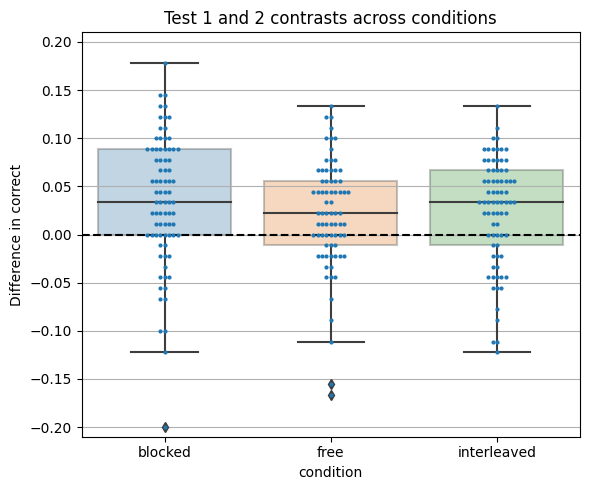

In [108]:
save = True
v = 'correct'

df = DF[~DF.feedbackOn][['rule', 'pid', 'condition', 'stage', 'correct', 'confidence']]
df = df.groupby(['rule', 'condition', 'pid', 'stage']).mean().reset_index()
df = df.sort_values(by=['rule', 'condition', 'pid', 'stage'])
df = df.groupby(['rule', 'condition', 'pid'])[['correct', 'confidence']].apply(lambda sdf: sdf.iloc[-1, :] - sdf.iloc[0, :]).reset_index()

fig, ax = plt.subplots(figsize=[6, 5])
sns.boxplot(y=v, x='condition', boxprops=dict(alpha=.3), data=df, ax=ax)
sns.swarmplot(y=v, x='condition', dodge=True, data=df, ax=ax, s=3)
ax.set_ylim(-0.21, 0.21)
ax.axhline(0, ls='--', color='k')
ax.set_ylabel(f'Difference in {v}')
ax.grid(axis='y')
plt.title('Test 1 and 2 contrasts across conditions')
fig.tight_layout()


display(df.head())
linmod = ols(f'{v} ~ condition', data=df).fit()
anova_table = anova_lm(linmod, typ=2)
print(f'ANOVA: effect of condition on difference in {v} between test 1 and 2')
display(anova_table)

if save:
    plt.savefig(f'plots/testsDiffPerCondition_{v}.png')